In [ ]:
import pandas as pd

# Dataset 1 — Appliances Energy Prediction (UCI)

In [25]:
df1 = pd.read_csv('/content/EX_01_AMOSTRA.csv')

In [26]:
df1.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,time,continuous,continuous,continuous,continuous,continuous,continuous,continuous,continuous
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-14 01:40:00,40,0,20.89,35.4,17.76,39.1633,20.29,36.9
3,2016-01-30 20:00:00,90,10,21.89,53.1,21.29,45.36,21.6333,49.2267
4,2016-03-15 03:00:00,50,0,21.39,35.5,17.6333,40.53,21.6667,35.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(f"Total de registros:{df1.shape[0]}")
print(f"Total de colunas:{df1.shape[1]}")

Total de registros:1976
Total de colunas:9


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        1975 non-null   object
 1   Appliances  1975 non-null   object
 2   lights      1975 non-null   object
 3   T1          1975 non-null   object
 4   RH_1        1975 non-null   object
 5   T2          1975 non-null   object
 6   RH_2        1975 non-null   object
 7   T3          1975 non-null   object
 8   RH_3        1975 non-null   object
dtypes: object(9)
memory usage: 139.1+ KB


In [ ]:
df1.describe()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1975,1975,1975,1975,1975,1975,1975,1975,1975
unique,1975,63,7,278,813,442,880,397,685
top,2016-05-15 09:00:00,50,0,21,37.7,19.2,40,22.39,38.4
freq,1,471,1520,47,23,39,17,51,23


# 2. Renomeie Appliances para Consumo_Eletrodomesticos e simplifique o nome de pelo menos três atributos ambientais.

In [ ]:
df1.rename(columns={'Appliances': 'Consumo_Eletrodomesticos',
                    'T1': 'Tempertura_1',
                    'T2': 'Temperatura_2',
                    'T3': 'Temperatura_3'}, inplace=True)

In [ ]:
df1.head()

,date,Consumo_Eletrodomesticos,lights,Tempertura_1,RH_1,Temperatura_2,RH_2,Temperatura_3,RH_3
0,time,continuous,continuous,continuous,continuous,continuous,continuous,continuous,continuous
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-14 01:40:00,40,0,20.89,35.4,17.76,39.1633,20.29,36.9
3,2016-01-30 20:00:00,90,10,21.89,53.1,21.29,45.36,21.6333,49.2267
4,2016-03-15 03:00:00,50,0,21.39,35.5,17.6333,40.53,21.6667,35.2


# 3. Determine o maior consumo de eletrodomésticos registrado na amostra.

In [ ]:
df1['Consumo_Eletrodomesticos'] = pd.to_numeric(df1['Consumo_Eletrodomesticos'], errors='coerce')
CMAX = df1.Consumo_Eletrodomesticos.max()
print(f"O maior consumo de eletrodomésticos registrado na amostra é: {CMAX}")

O maior consumo de eletrodomésticos registrado na amostra é: 770.0


# 4. Calcule um limiar correspondente a 70% do valor máximo e crie um DataFrame contendo somente os registros acima desse limite.  

In [ ]:
C70 = CMAX * 0.70
df2 = df1[df1['Consumo_Eletrodomesticos'] > threshold]
print(f"Limiar (70% de {CMAX}): {threshold}")
display(df2.head())

Limiar (70% de 770.0): 539.0


,date,Consumo_Eletrodomesticos,lights,Tempertura_1,RH_1,Temperatura_2,RH_2,Temperatura_3,RH_3
354,2016-05-26 17:10:00,620.0,0,24.39,44.3333,25.37,37.736,26.73,38.8633
429,2016-03-19 11:20:00,650.0,0,20.89,36.7,18.29,39.6633,21.2,36
455,2016-03-21 18:40:00,560.0,30,21.3567,36.09,19.5667,37.1633,21.6333,35.03
618,2016-05-14 17:50:00,570.0,10,24.89,32.6667,23.56,31.14,23.6,30.8233
698,2016-01-21 19:10:00,590.0,30,19.8567,47.6633,18.7,34.1,18.4267,37.8333


# 5. Conte os registros selecionados e calcule qual percentual da amostra eles representam.

In [ ]:
registros_maiores = df2.shape[0]
registros_totais = df1.shape[0]
porcentagem_acima = (num_records_above_threshold / total_records) * 100

print(f"Número de registros acima do limiar: {registros_maiores}")
print(f"Total de registros na amostra original: {registros_totais}")
print(f"Percentual de registros acima do limiar: {porcentagem_acima:.2f}%")

Número de registros acima do limiar: 22
Total de registros na amostra original: 1976
Percentual de registros acima do limiar: 1.11%


#6. Calcule a temperatura média de T1 e crie outro DataFrame c	ontendo simultaneamente consumo acima de 70% do máximo e temperatura acima da média.

In [ ]:
df1['Tempertura_1'] = pd.to_numeric(df1['Tempertura_1'], errors='coerce')


media_T1 = df1['Tempertura_1'].mean()
print(f"Temperatura média (Tempertura_1): {media_T1:.2f}")

df_filtered_temp_consumption = df1[(df1['Consumo_Eletrodomesticos'] > C70) & (df1['Tempertura_1'] > media_T1)]

print("\nRegistros com consumo acima de 70% do máximo E temperatura acima da média:")
display(df_filtered_temp_consumption.head())

Temperatura média (Tempertura_1): 21.66

Registros com consumo acima de 70% do máximo E temperatura acima da média:


,date,Consumo_Eletrodomesticos,lights,Tempertura_1,RH_1,Temperatura_2,RH_2,Temperatura_3,RH_3
354,2016-05-26 17:10:00,620.0,0,24.3900,44.3333,25.37,37.736,26.73,38.8633
618,2016-05-14 17:50:00,570.0,10,24.8900,32.6667,23.56,31.14,23.6,30.8233
918,2016-02-11 18:50:00,750.0,30,22.4300,43,21.9267,40.1333,21.23,42.5967
995,2016-02-09 19:10:00,690.0,10,22.5333,45.0267,22.0667,39.79,22.39,41.93
1184,2016-05-13 11:10:00,600.0,20,24.8900,48.1333,28.9175,37.9475,27.1,42.44


# 7. Compare os dois DataFrames e explique o efeito da inclusão da temperatura como segundo critério.

In [ ]:
print(f"Número de registros em df2 (apenas consumo > C70): {df2.shape[0]}")
print(f"Número de registros em df_filtered_temp_consumption (consumo > C70 E Tempertura_1 > media_T1): {df_filtered_temp_consumption.shape[0]}")

if df2.shape[0] > df_filtered_temp_consumption.shape[0]:
    difference = df2.shape[0] - df_filtered_temp_consumption.shape[0]
    print(f"\nA inclusão do critério de temperatura reduziu o número de registros em {difference}.")
else:
    print("\nA inclusão do critério de temperatura não reduziu ou aumentou o número de registros (o que seria inesperado). Remova nulos antes de comparar, ou verifique os filtros.")

Número de registros em df2 (apenas consumo > C70): 22
Número de registros em df_filtered_temp_consumption (consumo > C70 E Tempertura_1 > media_T1): 8

A inclusão do critério de temperatura reduziu o número de registros em 14.


A explicação é que o `df_filtered_temp_consumption` é um subconjunto do `df2`, pois a condição adicional de `Tempertura_1 > media_T1` atua como um filtro mais restritivo. Isso significa que, para ser incluído no `df_filtered_temp_consumption`, um registro não só precisa ter um consumo de eletrodomésticos elevado, mas também uma temperatura interna (T1) acima da média, o que reduz o número total de registros que satisfazem ambos os critérios simultaneamente.

# Dataset 2 — Steel Industry Energy Consumption (UCI)

# 1. Carregue a amostra e renomeie Usage_kWh para Consumo_kWh, simplificando também os nomes dos atributos de fator de potência.  

In [ ]:
df2 = pd.read_csv("EX_02_AMOSTRA.csv")
df2.rename(columns={'Usage_kWh': 'Consumo_kWh',
                    'Lagging_Current_Reactive.Power_kVarh': 'Corrente_Reativa_Atrasada_kVarh',
                    'Leading_Current_Reactive.Power_kVarh': 'Corrente_Reativa_Adiantada_kVarh',
                    'Lagging_Current_Power_Factor': 'Fator_Potência_Atrasada',
                    'Leading_Current_Power_Factor': 'Fator_Potência_Adiantada'
                    }, inplace=True)

# 2. Apresente uma inspeção inicial com head(), shape, info() e describe().

In [ ]:
df2.head()

,date,Consumo_kWh,Corrente_Reativa_Atrasada_kVarh,Leading_Current_Reactive_Power_kVarh,Fator_Potência_Atrasada,Fator_Potência_Adiantada,WeekStatus,Day_of_week,Load_Type
0,string,continuous,continuous,continuous,continuous,continuous,Weekday Weekend,Friday Monday Saturday Sunday Thursday Tuesday...,Light_Load Maximum_Load Medium_Load
1,meta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29/04/2018 07:15,2.88,3.82,0.00,60.20,100.00,Weekend,Sunday,Light_Load
3,04/10/2018 12:00,60.77,48.02,0.00,78.46,100.00,Weekday,Thursday,Maximum_Load
4,26/01/2018 11:30,120.42,59.65,0.00,89.61,100.00,Weekday,Friday,Maximum_Load


In [ ]:
print(f"Total de registros:{df2.shape[0]}")
print(f"Total de colunas:{df2.shape[1]}")

Total de registros:7010
Total de colunas:9


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   date                                  7010 non-null   object
 1   Consumo_kWh                           7009 non-null   object
 2   Corrente_Reativa_Atrasada_kVarh       7009 non-null   object
 3   Leading_Current_Reactive_Power_kVarh  7009 non-null   object
 4   Fator_Potência_Atrasada               7009 non-null   object
 5   Fator_Potência_Adiantada              7009 non-null   object
 6   WeekStatus                            7009 non-null   object
 7   Day_of_week                           7009 non-null   object
 8   Load_Type                             7009 non-null   object
dtypes: object(9)
memory usage: 493.0+ KB


In [ ]:
df2.describe()

,date,Consumo_kWh,Corrente_Reativa_Atrasada_kVarh,Leading_Current_Reactive_Power_kVarh,Fator_Potência_Atrasada,Fator_Potência_Adiantada,WeekStatus,Day_of_week,Load_Type
count,7010,7009,7009,7009,7009,7009,7009,7009,7009
unique,7010,1900,1396,639,3059,1307,3,8,4
top,14/04/2018 10:30,2.92,0.00,0.00,100.00,100.00,Weekday,Thursday,Light_Load
freq,1,135,1420,4711,1472,4886,5026,1048,3572


# 3. Determine o maior consumo registrado e calcule um limiar de 75% do consumo máximo.

In [ ]:
C75 = CMAX * 0.75
print(f"75% do CMAX ({CMAX}) é: {C75:.2f}")

75% do CMAX (770.0) é: 577.50


# 4. Crie um DataFrame contendo os registros acima desse limiar e calcule a quantidade e o percentual de registros.

In [ ]:
df_above_C75 = df1[df1['Consumo_Eletrodomesticos'] > C75]

num_records_above_C75 = df_above_C75.shape[0]
total_records_df1 = df1.shape[0]
percentage_above_C75 = (num_records_above_C75 / total_records_df1) * 100

print(f"Número de registros com Consumo_Eletrodomesticos acima de {C75:.2f}: {num_records_above_C75}")
print(f"Percentual de registros acima do limiar de 75% (em relação a df1): {percentage_above_C75:.2f}%")

display(df_above_C75.head())

Número de registros com Consumo_Eletrodomesticos acima de 577.50: 17
Percentual de registros acima do limiar de 75% (em relação a df1): 0.86%


,date,Consumo_Eletrodomesticos,lights,Tempertura_1,RH_1,Temperatura_2,RH_2,Temperatura_3,RH_3
354,2016-05-26 17:10:00,620.0,0,24.3900,44.3333,25.37,37.736,26.73,38.8633
429,2016-03-19 11:20:00,650.0,0,20.8900,36.7,18.29,39.6633,21.2,36
698,2016-01-21 19:10:00,590.0,30,19.8567,47.6633,18.7,34.1,18.4267,37.8333
746,2016-02-15 10:20:00,740.0,20,19.5000,42.1333,18.26,39.1967,19.89,39.1933
918,2016-02-11 18:50:00,750.0,30,22.4300,43,21.9267,40.1333,21.23,42.5967


# 6. Escolha um dos atributos de fator de potência, observe seus valores e defina um limite coerente para representar valores mais baixos

In [ ]:
# Convertendo as colunas de fator de potência para numérico
df2['Fator_Potência_Atrasada'] = pd.to_numeric(df2['Fator_Potência_Atrasada'], errors='coerce')
df2['Fator_Potência_Adiantada'] = pd.to_numeric(df2['Fator_Potência_Adiantada'], errors='coerce')

# Exibindo estatísticas descritivas para 'Fator_Potência_Atrasada'
print("Estatísticas descritivas para 'Fator_Potência_Atrasada':")
display(df2['Fator_Potência_Atrasada'].describe())

# Definindo um limite para representar valores mais baixos. Geralmente, um fator de potência abaixo de 80% (ou 0.8) é considerado baixo.
# Considerando que os valores parecem estar em uma escala de 0 a 100, um limite coerente seria 80.
lower_pf_limit = 80.0
print(f"\nDefinindo um limite de {lower_pf_limit} para 'Fator_Potência_Atrasada' para representar valores mais baixos.")

Estatísticas descritivas para 'Fator_Potência_Atrasada':


,Fator_Potência_Atrasada
count,7008.000000
mean,80.672277
std,18.869855
min,37.870000
25%,63.602500
50%,87.990000
75%,98.842500
max,100.000000



Definindo um limite de 80.0 para 'Fator_Potência_Atrasada' para representar valores mais baixos.


# 7. Crie um novo DataFrame contendo simultaneamente consumo elevado e fator de potência abaixo do limite escolhido.

In [ ]:
df2['Consumo_kWh'] = pd.to_numeric(df2['Consumo_kWh'], errors='coerce')

CMAX_df2 = df2['Consumo_kWh'].max()
C75_df2 = CMAX_df2 * 0.75

print(f"Consumo Máximo (df2): {CMAX_df2:.2f}")
print(f"Limiar de 75% do Consumo Máximo (df2): {C75_df2:.2f}")

df_high_consumption_low_power_factor = df2[
    (df2['Consumo_kWh'] > C75_df2) &
    (df2['Fator_Potência_Atrasada'] < lower_pf_limit)
]

print(f"\nNúmero de registros com consumo elevado E fator de potência atrasada abaixo de {lower_pf_limit}:{df_high_consumption_low_power_factor.shape[0]}")
display(df_high_consumption_low_power_factor.head())

Consumo Máximo (df2): 153.14
Limiar de 75% do Consumo Máximo (df2): 114.85

Número de registros com consumo elevado E fator de potência atrasada abaixo de 80.0:0


,date,Consumo_kWh,Corrente_Reativa_Atrasada_kVarh,Leading_Current_Reactive_Power_kVarh,Fator_Potência_Atrasada,Fator_Potência_Adiantada,WeekStatus,Day_of_week,Load_Type


# 8. Explique por que esse segundo conjunto de registros pode merecer maior atenção da equipe de energia.

O segundo conjunto de registros, que identifica simultaneamente períodos de **alto consumo de energia (Consumo_kWh)** e **baixo fator de potência atrasada (Fator_Potência_Atrasada < 80.0)**, merece maior atenção da equipe de energia por várias razões críticas:

1.  **Aumento dos Custos de Energia:** Um baixo fator de potência significa que a empresa está pagando por energia reativa que não realiza trabalho útil, mas que precisa ser fornecida pela concessionária. Isso pode levar a **multas e sobretaxas** na conta de energia, impactando diretamente os custos operacionais.

2.  **Ineficiência Operacional:** Um fator de potência baixo indica que o sistema elétrico está operando de forma ineficiente. Equipamentos que demandam muita energia reativa (como motores de indução e transformadores) podem estar sobrecarregados, levando a:
    *   **Perdas de Energia:** Mais energia é dissipada como calor nos condutores, aumentando as perdas no sistema de distribuição.
    *   **Quedas de Tensão:** Aumenta a corrente nos circuitos, causando quedas de tensão que podem afetar o desempenho de outros equipamentos.

3.  **Vida Útil Reduzida dos Equipamentos:** A operação sob condições de baixo fator de potência e alta corrente pode gerar calor excessivo nos equipamentos, acelerando seu desgaste e reduzindo sua vida útil, o que implica em custos de manutenção e substituição mais elevados.

4.  **Oportunidade de Otimização:** Identificar esses períodos e equipamentos específicos com baixo fator de potência permite à equipe de energia propor soluções direcionadas, como a instalação de bancos de capacitores para correção do fator de potência. Isso pode resultar em:
    *   **Redução imediata dos custos** com energia.
    *   **Melhora da qualidade da energia** e estabilidade do sistema.
    *   **Aumento da capacidade de carga** da instalação elétrica existente, evitando a necessidade de upgrades caros na infraestrutura.

Em resumo, focar nesses registros permite à equipe de energia não apenas mitigar problemas existentes, mas também implementar melhorias que resultarão em economias significativas e uma operação mais robusta e sustentável.

# Dataset 3 — Power Consumption of Tetouan City

In [8]:
dados = pd.read_csv('tetouan_amostra.csv')

In [9]:
dados.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'Zone 1 Power Consumption', 'Zone 2  Power Consumption',
       'Zone 3  Power Consumption'],
      dtype='object')

In [10]:
dados = dados.rename(columns={
    'Zone 1 Power Consumption': 'Consumo_Zona_1',
    'Zone 2  Power Consumption': 'Consumo_Zona_2',
    'Zone 3  Power Consumption': 'Consumo_Zona_3'
})

In [11]:
dados.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'Consumo_Zona_1',
       'Consumo_Zona_2', 'Consumo_Zona_3'],
      dtype='object')

In [12]:
max_zona_1 = dados['Consumo_Zona_1'].max()
max_zona_2 = dados['Consumo_Zona_2'].max()
max_zona_3 = dados['Consumo_Zona_3'].max()

print('Máximo Zona 1:', max_zona_1)
print('Máximo Zona 2:', max_zona_2)
print('Máximo Zona 3:', max_zona_3)

Máximo Zona 1: 51571.49834
Máximo Zona 2: 36437.2
Máximo Zona 3: 47441.7


In [13]:
if max_zona_1 > max_zona_2 and max_zona_1 > max_zona_3:
    print('A Zona 1 apresenta o maior pico de consumo.')
elif max_zona_2 > max_zona_1 and max_zona_2 > max_zona_3:
    print('A Zona 2 apresenta o maior pico de consumo.')
else:
    print('A Zona 3 apresenta o maior pico de consumo.')

A Zona 1 apresenta o maior pico de consumo.


In [14]:
limite_70 = max_zona_1 * 0.70

print('70% do valor máximo:', limite_70)

70% do valor máximo: 36100.048837999995


In [15]:
df_alto_consumo = dados[
    dados['Consumo_Zona_1'] > limite_70
]

In [16]:
df_alto_consumo.head()

,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
3,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.1,25089.7
8,12/10/2017 17:50,14.66,65.92,0.075,37286.69202,30716.2,15834.8
12,6/5/2017 23:30,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,8/23/2017 17:50,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,6/22/2017 2:40,19.20,65.81,4.924,40676.02649,24754.7,25095.9


In [17]:
quantidade = df_alto_consumo.shape[0]

print('Quantidade de registros:', quantidade)

Quantidade de registros: 2388


In [18]:
percentual = quantidade / dados.shape[0] * 100

print(f'Percentual: {percentual:.2f}%')

Percentual: 30.37%


In [19]:
temperatura_media = dados['Temperature'].mean()

print('Temperatura média:', temperatura_media)

Temperatura média: 18.78937631947094


In [20]:
df_consumo_temperatura = dados[
    (dados['Consumo_Zona_1'] > limite_70) &
    (dados['Temperature'] > temperatura_media)
]

In [21]:
df_consumo_temperatura.head()

,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
12,6/5/2017 23:30,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,8/23/2017 17:50,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,6/22/2017 2:40,19.20,65.81,4.924,40676.02649,24754.7,25095.9
21,8/23/2017 13:50,27.11,43.35,4.906,40256.07103,27416.3,25453.5
25,7/12/2017 9:50,26.92,70.20,4.909,36511.89369,25906.3,25654.9


In [22]:
quantidade_2 = df_consumo_temperatura.shape[0]

print('Quantidade de registros:', quantidade_2)

Quantidade de registros: 1597


In [23]:
percentual_2 = quantidade_2 / dados.shape[0] * 100

print(f'Percentual: {percentual_2:.2f}%')

Percentual: 20.31%


In [24]:
print('Registros apenas com consumo acima de 70%:', quantidade)
print('Registros com consumo acima de 70% e temperatura acima da média:', quantidade_2)

Registros apenas com consumo acima de 70%: 2388
Registros com consumo acima de 70% e temperatura acima da média: 1597


### Comparação dos resultados

O primeiro DataFrame contém os registros em que o consumo da zona com maior pico está acima de 70% do seu valor máximo.

Após incluir a condição de temperatura acima da média, a quantidade de registros diminuiu. Isso acontece porque o segundo filtro é mais restritivo, já que o registro precisa atender simultaneamente às duas condições: apresentar consumo elevado e temperatura acima da média.



# Dataset 4 — Solar Power Generation Data (Kaggle)

**Etapa B — Python / Pandas**

---

### Situação

Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração
e identificar quais inversores aparecem com maior frequência nesses momentos.

O foco desta atividade é o **arquivo de geração da planta**, sem junção com o arquivo de
sensores. Essa restrição é importante e será retomada na resposta interpretativa final.

### Dados de entrada

Amostra aleatória de 20% dos registros, gerada na Etapa A com o widget `Data Sampler`
do Orange Data Mining e exportada em CSV.

### Integrante

- Matheus Sabino — RM 572907

---

## 0. Preparação do ambiente

Execute a célula abaixo e selecione o CSV exportado do Orange na Etapa A.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Pandas:', pd.__version__)

Pandas: 2.2.3


In [ ]:
try:
    from google.colab import files
    import io
    enviado = files.upload()
    NOME_ARQUIVO = list(enviado.keys())[0]
    dados = pd.read_csv(io.BytesIO(enviado[NOME_ARQUIVO]))
except ImportError:
    NOME_ARQUIVO = 'amostra_solar_20.csv'
    dados = pd.read_csv(NOME_ARQUIVO)

print('Arquivo carregado:', NOME_ARQUIVO)
print('Dimensões:', dados.shape)

Saving amostra_solar_20.csv to amostra_solar_20.csv
Arquivo carregado: amostra_solar_20.csv
Dimensões: (13756, 6)


---

## Exercício 1 — Carregamento e renomeação das variáveis

Os nomes originais do dataset estão em inglês e abreviados. A renomeação torna as
condições de filtro mais legíveis e explicita a grandeza física de cada coluna.

In [ ]:
print('Colunas originais:')
for c in dados.columns:
    print(' -', c)

Colunas originais:
 - DATE_TIME
 - SOURCE_KEY
 - DC_POWER
 - AC_POWER
 - DAILY_YIELD
 - TOTAL_YIELD


In [ ]:
novos_nomes = {
    'DC_POWER':    'Potencia_CC',
    'AC_POWER':    'Potencia_CA',
    'DAILY_YIELD': 'Geracao_Diaria',
    'TOTAL_YIELD': 'Geracao_Acumulada',
}

novos_nomes = {k: v for k, v in novos_nomes.items() if k in dados.columns}
dados = dados.rename(columns=novos_nomes)

print('Renomeações aplicadas:')
for antigo, novo in novos_nomes.items():
    print(f'  {antigo:<12} ->  {novo}')

print('\nColunas após a renomeação:')
print(list(dados.columns))

Renomeações aplicadas:
  DC_POWER     ->  Potencia_CC
  AC_POWER     ->  Potencia_CA
  DAILY_YIELD  ->  Geracao_Diaria
  TOTAL_YIELD  ->  Geracao_Acumulada

Colunas após a renomeação:
['DATE_TIME', 'SOURCE_KEY', 'Potencia_CC', 'Potencia_CA', 'Geracao_Diaria', 'Geracao_Acumulada']


**Observação sobre `SOURCE_KEY` e `DATE_TIME`:** essas duas colunas foram mantidas com o
nome original de propósito.

- `SOURCE_KEY` é o identificador do inversor e é citado explicitamente no enunciado do
  Exercício 6. Preservar o nome mantém a rastreabilidade com o dataset de origem.
- `DATE_TIME` é o carimbo de tempo do registro, coletado em intervalos de 15 minutos.

**Sobre as grandezas renomeadas:**

| Nome original | Novo nome | O que representa |
|---|---|---|
| `DC_POWER` | `Potencia_CC` | Potência em corrente contínua, gerada pelos módulos fotovoltaicos |
| `AC_POWER` | `Potencia_CA` | Potência em corrente alternada, na saída do inversor — é a energia efetivamente injetada na rede |
| `DAILY_YIELD` | `Geracao_Diaria` | Energia acumulada desde o início do dia (reinicia à meia-noite) |
| `TOTAL_YIELD` | `Geracao_Acumulada` | Energia acumulada desde a instalação do inversor (contador crescente) |

A distinção entre CC e CA é o que justifica a escolha do enunciado pela potência CA nos
exercícios seguintes: é ela que representa a entrega real da usina, já descontadas as
perdas de conversão do inversor.

---

## Exercício 2 — Inspeção inicial

Apresentação de `head()`, `shape`, `info()` e `describe()`.

In [ ]:
dados.head()

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Acumulada
0,10-06-2020 19:00,uHbuxQJl8lW7ozc,0.00,0.00,"6,645.00","7,240,508.00"
1,28-05-2020 00:15,rGa61gmuvPhdLxV,0.00,0.00,0.00,"7,206,549.00"
2,17-05-2020 15:15,sjndEbLyjtCKgGv,"7,333.88",718.06,"6,442.00","7,036,055.00"
3,01-06-2020 04:15,ih0vzX44oOqAx2f,0.00,0.00,0.00,"6,308,232.00"
4,17-05-2020 09:00,z9Y9gH1T5YWrNuG,"7,665.50",750.44,961.38,"7,021,701.38"


In [ ]:
linhas_amostra, colunas_amostra = dados.shape
print(f'Registros (linhas):  {linhas_amostra}')
print(f'Atributos (colunas): {colunas_amostra}')

Registros (linhas):  13756
Atributos (colunas): 6


In [ ]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 13756 entries, 0 to 13755
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DATE_TIME          13756 non-null  str    
 1   SOURCE_KEY         13756 non-null  str    
 2   Potencia_CC        13756 non-null  float64
 3   Potencia_CA        13756 non-null  float64
 4   Geracao_Diaria     13756 non-null  float64
 5   Geracao_Acumulada  13756 non-null  float64
dtypes: float64(4), str(2)
memory usage: 644.9 KB


In [ ]:
dados.describe()

,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Acumulada
count,"13,756.00","13,756.00","13,756.00","13,756.00"
mean,"3,135.85",306.70,"3,319.24","6,978,829.42"
std,"4,023.07",393.12,"3,142.25","416,216.39"
min,0.00,0.00,0.00,"6,183,645.00"
25%,0.00,0.00,0.00,"6,509,779.00"
50%,370.07,35.77,"2,730.43","7,146,218.38"
75%,"6,350.56",622.07,"6,293.79","7,267,996.00"
max,"14,416.14","1,405.59","9,163.00","7,846,821.00"


In [ ]:
ausentes = dados.isnull().sum()
print('Valores ausentes por atributo:')
print(ausentes)
print(f'\nTotal na amostra: {ausentes.sum()}')

Valores ausentes por atributo:
DATE_TIME            0
SOURCE_KEY           0
Potencia_CC          0
Potencia_CA          0
Geracao_Diaria       0
Geracao_Acumulada    0
dtype: int64

Total na amostra: 0


In [ ]:
zeros_ca = (dados['Potencia_CA'] == 0).sum()
zeros_cc = (dados['Potencia_CC'] == 0).sum()

print(f'Registros com Potencia_CA igual a zero: {zeros_ca}  ({zeros_ca/len(dados)*100:.2f}%)')
print(f'Registros com Potencia_CC igual a zero: {zeros_cc}  ({zeros_cc/len(dados)*100:.2f}%)')
print(f'\nFaixa de Potencia_CA: {dados["Potencia_CA"].min():.2f} a {dados["Potencia_CA"].max():.2f} kW')

Registros com Potencia_CA igual a zero: 6444  (46.85%)
Registros com Potencia_CC igual a zero: 6444  (46.85%)

Faixa de Potencia_CA: 0.00 a 1405.59 kW


In [ ]:
n_inversores = dados['SOURCE_KEY'].nunique()
print(f'Inversores distintos (SOURCE_KEY): {n_inversores}')
print(f'\nRegistros por inversor — cinco primeiros:')
print(dados['SOURCE_KEY'].value_counts().head())
print(f'\nMínimo de registros de um inversor: {dados["SOURCE_KEY"].value_counts().min()}')
print(f'Máximo de registros de um inversor: {dados["SOURCE_KEY"].value_counts().max()}')

Inversores distintos (SOURCE_KEY): 22

Registros por inversor — cinco primeiros:
SOURCE_KEY
z9Y9gH1T5YWrNuG    672
WRmjgnKYAwPKWDb    651
ih0vzX44oOqAx2f    638
1IF53ai7Xc0U56Y    635
McdE0feGgRqW7Ca    635
Name: count, dtype: int64

Mínimo de registros de um inversor: 594
Máximo de registros de um inversor: 672


In [ ]:
perc_zeros = zeros_ca / len(dados) * 100
media_ca = dados['Potencia_CA'].mean()
max_ca_insp = dados['Potencia_CA'].max()

display(Markdown(f'''
### Interpretação da inspeção inicial

- A amostra contém **{linhas_amostra:,} registros**, **{colunas_amostra} atributos** e
  **{n_inversores} inversores distintos**.
- Total de valores ausentes: **{ausentes.sum()}**.
- **{perc_zeros:.2f}%** dos registros têm potência CA igual a zero
  ({zeros_ca:,} de {linhas_amostra:,}). **Isso não é erro de medição.** Os dados são
  coletados a cada 15 minutos ao longo das 24 horas, e durante o período noturno não há
  irradiação solar — logo, não há geração. Uma usina fotovoltaica produz apenas durante o
  dia, e o dataset registra fielmente esse comportamento.
- A `Potencia_CA` varia de **0 a {max_ca_insp:,.2f} kW**, com média de apenas
  **{media_ca:,.2f} kW**. A distância entre média e máximo é consequência direta da massa de
  zeros noturnos, que puxa a média para baixo. É por isso que o exercício define o limiar a
  partir do **máximo**, e não da média: um limiar baseado na média capturaria praticamente
  todo o período diurno e não isolaria os picos.
'''))


### Interpretação da inspeção inicial

- A amostra contém **13,756 registros**, **6 atributos** e
  **22 inversores distintos**.
- Total de valores ausentes: **0**.
- **46.85%** dos registros têm potência CA igual a zero
  (6,444 de 13,756). **Isso não é erro de medição.** Os dados são
  coletados a cada 15 minutos ao longo das 24 horas, e durante o período noturno não há
  irradiação solar — logo, não há geração. Uma usina fotovoltaica produz apenas durante o
  dia, e o dataset registra fielmente esse comportamento.
- A `Potencia_CA` varia de **0 a 1,405.59 kW**, com média de apenas
  **306.70 kW**. A distância entre média e máximo é consequência direta da massa de
  zeros noturnos, que puxa a média para baixo. É por isso que o exercício define o limiar a
  partir do **máximo**, e não da média: um limiar baseado na média capturaria praticamente
  todo o período diurno e não isolaria os picos.


---

## Exercício 3 — Maior potência CA registrada

In [ ]:
POTENCIA_CA_MAX = dados['Potencia_CA'].max()

print(f'Maior potência CA registrada na amostra: {POTENCIA_CA_MAX:.2f} kW')

registro_pico = dados.loc[dados['Potencia_CA'].idxmax()]
print('\nRegistro correspondente ao pico:')
print(registro_pico)

Maior potência CA registrada na amostra: 1405.59 kW

Registro correspondente ao pico:
DATE_TIME            14-06-2020 14:00
SOURCE_KEY            adLQvlD726eNBSB
Potencia_CC                 14,416.14
Potencia_CA                  1,405.59
Geracao_Diaria               5,471.29
Geracao_Acumulada        6,502,967.29
Name: 13172, dtype: object


---

## Exercício 4 — Limiar de 70% da potência CA máxima

O limiar é **relativo aos próprios dados**. Em vez de fixar um valor arbitrário em kW, usa-se
um percentual do maior valor observado. Isso torna o critério transferível para outra usina,
de porte diferente, sem precisar recalibrar o número.

In [ ]:
LIMIAR_70 = 0.70 * POTENCIA_CA_MAX

print(f'Potência CA máxima:      {POTENCIA_CA_MAX:.2f} kW')
print(f'Limiar de 70% do máximo: {LIMIAR_70:.2f} kW')

Potência CA máxima:      1405.59 kW
Limiar de 70% do máximo: 983.91 kW


In [ ]:
print('Posição do limiar na distribuição de Potencia_CA:\n')
print(f'  Mínimo:  {dados["Potencia_CA"].min():>10.2f} kW')
print(f'  Média:   {dados["Potencia_CA"].mean():>10.2f} kW')
print(f'  Mediana: {dados["Potencia_CA"].median():>10.2f} kW')
print(f'  LIMIAR:  {LIMIAR_70:>10.2f} kW   <---')
print(f'  Máximo:  {POTENCIA_CA_MAX:>10.2f} kW')

Posição do limiar na distribuição de Potencia_CA:

  Mínimo:        0.00 kW
  Média:       306.70 kW
  Mediana:      35.77 kW
  LIMIAR:      983.91 kW   <---
  Máximo:     1405.59 kW


---

## Exercício 5 — DataFrame de alta geração: quantidade e percentual

In [ ]:
df_alta_geracao = dados[dados['Potencia_CA'] > LIMIAR_70]

qtd_alta = len(df_alta_geracao)
perc_alta = qtd_alta / len(dados) * 100

print(f'Registros acima de 70% da potência CA máxima: {qtd_alta}')
print(f'Total de registros na amostra:                {len(dados)}')
print(f'Percentual que representam:                   {perc_alta:.2f}%')

Registros acima de 70% da potência CA máxima: 1185
Total de registros na amostra:                13756
Percentual que representam:                   8.61%


In [ ]:
df_alta_geracao.head(10)

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Acumulada
11,26-05-2020 12:15,bvBOhCH3iADSZry,"11,830.14","1,153.83","4,028.14","6,396,364.14"
46,15-06-2020 14:30,wCURE6d3bPkepu2,"10,571.29","1,032.07","5,366.57","7,015,064.57"
48,25-05-2020 10:15,z9Y9gH1T5YWrNuG,"11,050.14","1,079.86","2,174.29","7,082,812.29"
72,13-06-2020 11:30,7JYdWkrLSPkdwr4,"11,094.50","1,082.44","3,570.25","7,815,987.25"
76,07-06-2020 13:00,VHMLBKoKgIrUVDU,"12,663.43","1,234.69","4,976.71","7,382,965.71"
85,03-06-2020 12:30,pkci93gMrogZuBj,"11,015.43","1,075.59","3,758.14","7,311,408.14"
131,17-05-2020 11:15,1BY6WEcLGh8j5v7,"10,160.14",991.83,"2,945.14","6,274,550.14"
135,07-06-2020 13:00,ZnxXDlPa8U1GXgE,"12,618.75","1,230.31","4,942.12","6,697,996.12"
144,25-05-2020 13:45,ZnxXDlPa8U1GXgE,"11,796.14","1,150.13","6,383.29","6,602,139.29"
169,21-05-2020 13:00,z9Y9gH1T5YWrNuG,"12,289.86","1,198.67","4,912.57","7,054,173.57"


In [ ]:
dados_com_geracao = dados[dados['Potencia_CA'] > 0]
perc_sobre_ativos = qtd_alta / len(dados_com_geracao) * 100

print(f'Registros com geração maior que zero: {len(dados_com_geracao)}')
print(f'Registros de alta geração:            {qtd_alta}')
print(f'Percentual sobre os registros ativos: {perc_sobre_ativos:.2f}%')

Registros com geração maior que zero: 7312
Registros de alta geração:            1185
Percentual sobre os registros ativos: 16.21%


In [ ]:
display(Markdown(f'''
### Interpretação

Os **{qtd_alta:,} registros** de alta geração representam **{perc_alta:.2f}%** da amostra
completa, mas **{perc_sobre_ativos:.2f}%** quando calculados apenas sobre os
{len(dados_com_geracao):,} intervalos em que a usina estava efetivamente produzindo.

Os dois números respondem a perguntas diferentes e vale apresentar ambos. O primeiro descreve
a operação ao longo do dia inteiro; o segundo descreve o comportamento durante o período de
sol. Reportar apenas o primeiro subestimaria a frequência com que a usina opera perto do pico,
porque cerca de metade da série é composta por registros noturnos com geração nula.

Em qualquer das duas leituras, a operação próxima ao pico é um regime **minoritário**: a usina
passa a maior parte do tempo produtivo abaixo de {LIMIAR_70:,.2f} kW. Isso é esperado, já que
a potência acompanha a curva de irradiância ao longo do dia e só se aproxima do máximo nas
horas centrais.
'''))


### Interpretação

Os **1,185 registros** de alta geração representam **8.61%** da amostra
completa, mas **16.21%** quando calculados apenas sobre os
7,312 intervalos em que a usina estava efetivamente produzindo.

Os dois números respondem a perguntas diferentes e vale apresentar ambos. O primeiro descreve
a operação ao longo do dia inteiro; o segundo descreve o comportamento durante o período de
sol. Reportar apenas o primeiro subestimaria a frequência com que a usina opera perto do pico,
porque cerca de metade da série é composta por registros noturnos com geração nula.

Em qualquer das duas leituras, a operação próxima ao pico é um regime **minoritário**: a usina
passa a maior parte do tempo produtivo abaixo de 983.91 kW. Isso é esperado, já que
a potência acompanha a curva de irradiância ao longo do dia e só se aproxima do máximo nas
horas centrais.


---

## Exercício 6 — `value_counts()` em `SOURCE_KEY` no recorte de alta geração

Contagem de quantas vezes cada inversor aparece entre os registros de alta geração.

In [ ]:
contagem_inversores = df_alta_geracao['SOURCE_KEY'].value_counts()

print('Frequência de cada inversor nos registros de alta geração:\n')
print(contagem_inversores)

Frequência de cada inversor nos registros de alta geração:

SOURCE_KEY
adLQvlD726eNBSB    68
McdE0feGgRqW7Ca    65
ZnxXDlPa8U1GXgE    63
pkci93gMrogZuBj    62
ZoEaEvLYb1n2sOq    61
1IF53ai7Xc0U56Y    59
YxYtjZvoooNbGkE    58
sjndEbLyjtCKgGv    57
z9Y9gH1T5YWrNuG    56
uHbuxQJl8lW7ozc    55
zVJPv84UY57bAof    54
ih0vzX44oOqAx2f    53
zBIq5rxdHJRwDNY    53
WRmjgnKYAwPKWDb    52
VHMLBKoKgIrUVDU    51
3PZuoBAID5Wc2HD    51
iCRJl6heRkivqQ3    51
wCURE6d3bPkepu2    49
7JYdWkrLSPkdwr4    43
rGa61gmuvPhdLxV    43
1BY6WEcLGh8j5v7    42
bvBOhCH3iADSZry    39
Name: count, dtype: int64


In [ ]:
print('Participação percentual de cada inversor no recorte de alta geração:\n')
print((df_alta_geracao['SOURCE_KEY'].value_counts(normalize=True) * 100).round(2))

Participação percentual de cada inversor no recorte de alta geração:

SOURCE_KEY
adLQvlD726eNBSB   5.74
McdE0feGgRqW7Ca   5.49
ZnxXDlPa8U1GXgE   5.32
pkci93gMrogZuBj   5.23
ZoEaEvLYb1n2sOq   5.15
1IF53ai7Xc0U56Y   4.98
YxYtjZvoooNbGkE   4.89
sjndEbLyjtCKgGv   4.81
z9Y9gH1T5YWrNuG   4.73
uHbuxQJl8lW7ozc   4.64
zVJPv84UY57bAof   4.56
ih0vzX44oOqAx2f   4.47
zBIq5rxdHJRwDNY   4.47
WRmjgnKYAwPKWDb   4.39
VHMLBKoKgIrUVDU   4.30
3PZuoBAID5Wc2HD   4.30
iCRJl6heRkivqQ3   4.30
wCURE6d3bPkepu2   4.14
7JYdWkrLSPkdwr4   3.63
rGa61gmuvPhdLxV   3.63
1BY6WEcLGh8j5v7   3.54
bvBOhCH3iADSZry   3.29
Name: proportion, dtype: float64


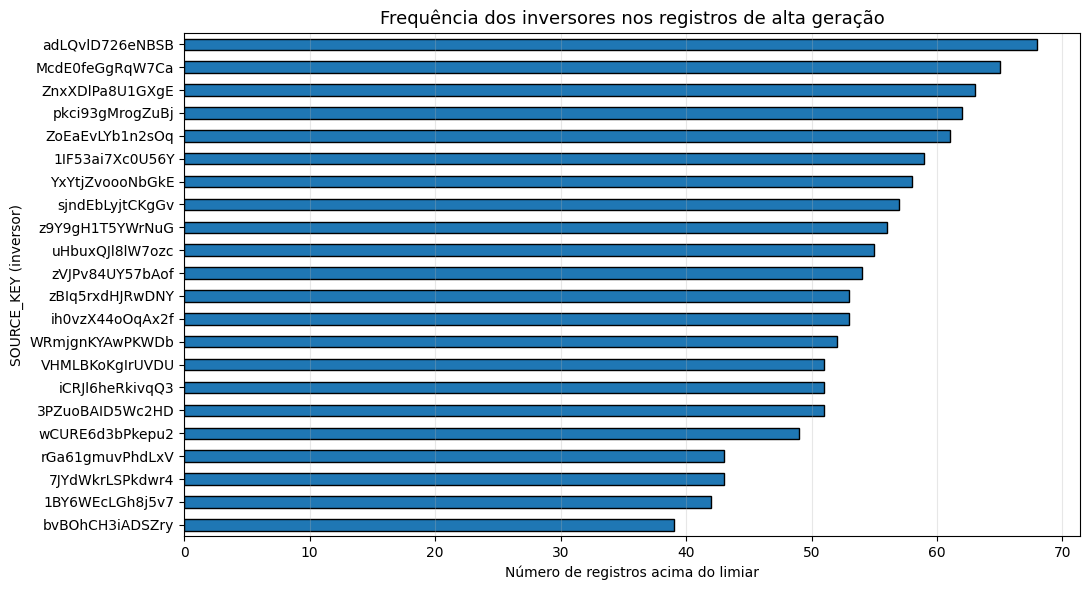

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

contagem_inversores.sort_values().plot(kind='barh', ax=ax, edgecolor='black')
ax.set_title('Frequência dos inversores nos registros de alta geração', fontsize=13)
ax.set_xlabel('Número de registros acima do limiar')
ax.set_ylabel('SOURCE_KEY (inversor)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---

## Exercício 7 — Inversor mais frequente e o que esse recorte permite observar

In [ ]:
inversor_top = contagem_inversores.index[0]
freq_top = contagem_inversores.iloc[0]

inversor_ultimo = contagem_inversores.index[-1]
freq_ultimo = contagem_inversores.iloc[-1]

print(f'Inversor mais frequente na alta geração: {inversor_top}')
print(f'  Registros acima do limiar: {freq_top}')
print(f'  Participação no recorte:   {freq_top/qtd_alta*100:.2f}%')
print()
print(f'Inversor menos frequente: {inversor_ultimo}  ({freq_ultimo} registros)')
print(f'Inversores presentes no recorte: {len(contagem_inversores)} de {n_inversores} da amostra')

Inversor mais frequente na alta geração: adLQvlD726eNBSB
  Registros acima do limiar: 68
  Participação no recorte:   5.74%

Inversor menos frequente: bvBOhCH3iADSZry  (39 registros)
Inversores presentes no recorte: 22 de 22 da amostra


### Verificação complementar: normalizando pelo total de registros de cada inversor

A contagem bruta acima responde *"qual inversor aparece mais"*. Mas aparecer mais pode
significar duas coisas diferentes: gerar mais, ou simplesmente **ter mais registros na
amostra**. Se um inversor ficou fora de operação por alguns dias, ou se a amostragem
aleatória de 20% o contemplou menos, ele terá menos chances de aparecer — independentemente
do seu desempenho.

A célula abaixo separa esses dois efeitos, calculando a **taxa** de alta geração de cada
inversor: registros acima do limiar dividido pelo total de registros daquele inversor.

In [ ]:
total_por_inversor = dados['SOURCE_KEY'].value_counts()
alta_por_inversor = df_alta_geracao['SOURCE_KEY'].value_counts()

analise = pd.DataFrame({
    'Registros_totais': total_por_inversor,
    'Registros_alta_geracao': alta_por_inversor
}).fillna(0)

analise['Registros_alta_geracao'] = analise['Registros_alta_geracao'].astype(int)
analise['Taxa_alta_geracao_%'] = (
    analise['Registros_alta_geracao'] / analise['Registros_totais'] * 100
).round(2)

analise = analise.sort_values('Registros_alta_geracao', ascending=False)
analise

,Registros_totais,Registros_alta_geracao,Taxa_alta_geracao_%
SOURCE_KEY,,,
adLQvlD726eNBSB,629,68,10.81
McdE0feGgRqW7Ca,635,65,10.24
ZnxXDlPa8U1GXgE,617,63,10.21
pkci93gMrogZuBj,603,62,10.28
ZoEaEvLYb1n2sOq,633,61,9.64
1IF53ai7Xc0U56Y,635,59,9.29
YxYtjZvoooNbGkE,631,58,9.19
sjndEbLyjtCKgGv,594,57,9.60
z9Y9gH1T5YWrNuG,672,56,8.33


In [ ]:
ranking_contagem = analise.sort_values('Registros_alta_geracao', ascending=False).index.tolist()
ranking_taxa = analise.sort_values('Taxa_alta_geracao_%', ascending=False).index.tolist()

print('Primeiro colocado por CONTAGEM BRUTA:', ranking_contagem[0])
print('Primeiro colocado por TAXA:          ', ranking_taxa[0])
print()
if ranking_contagem[0] == ranking_taxa[0]:
    print('As duas ordenações apontam o mesmo inversor no topo.')
    print('A frequência bruta, neste caso, não está sendo distorcida pela')
    print('quantidade desigual de registros entre inversores.')
else:
    print('As duas ordenações apontam inversores DIFERENTES no topo.')
    print('Isso mostra que a contagem bruta estava sendo influenciada pela')
    print('quantidade desigual de registros entre os inversores.')

print()
print(f'Variação no total de registros por inversor: '
      f'{analise["Registros_totais"].min()} a {analise["Registros_totais"].max()}')

Primeiro colocado por CONTAGEM BRUTA: adLQvlD726eNBSB
Primeiro colocado por TAXA:           adLQvlD726eNBSB

As duas ordenações apontam o mesmo inversor no topo.
A frequência bruta, neste caso, não está sendo distorcida pela
quantidade desigual de registros entre inversores.

Variação no total de registros por inversor: 594 a 672


In [ ]:
print('=' * 62)
print('SÍNTESE DOS RESULTADOS — DATASET 4 (SOLAR POWER GENERATION)')
print('=' * 62)
print(f'Arquivo analisado:                     {NOME_ARQUIVO}')
print(f'Registros na amostra (20%):            {len(dados)}')
print(f'Inversores distintos:                  {n_inversores}')
print(f'Registros com potência CA zero:        {zeros_ca} ({zeros_ca/len(dados)*100:.2f}%)')
print('-' * 62)
print(f'Potência CA máxima:                    {POTENCIA_CA_MAX:.2f} kW')
print(f'Limiar de 70%:                         {LIMIAR_70:.2f} kW')
print('-' * 62)
print(f'Registros de alta geração:             {qtd_alta} ({perc_alta:.2f}% da amostra)')
print(f'  sobre os registros com geração > 0:  {perc_sobre_ativos:.2f}%')
print('-' * 62)
print(f'Inversor mais frequente (contagem):    {inversor_top} ({freq_top} registros)')
print(f'Inversor com maior taxa:               {ranking_taxa[0]} '
      f'({analise.loc[ranking_taxa[0], "Taxa_alta_geracao_%"]:.2f}%)')
print('=' * 62)

SÍNTESE DOS RESULTADOS — DATASET 4 (SOLAR POWER GENERATION)
Arquivo analisado:                     amostra_solar_20.csv
Registros na amostra (20%):            13756
Inversores distintos:                  22
Registros com potência CA zero:        6444 (46.85%)
--------------------------------------------------------------
Potência CA máxima:                    1405.59 kW
Limiar de 70%:                         983.91 kW
--------------------------------------------------------------
Registros de alta geração:             1185 (8.61% da amostra)
  sobre os registros com geração > 0:  16.21%
--------------------------------------------------------------
Inversor mais frequente (contagem):    adLQvlD726eNBSB (68 registros)
Inversor com maior taxa:               adLQvlD726eNBSB (10.81%)


In [ ]:
if ranking_contagem[0] == ranking_taxa[0]:
    obs_ranking = (
        f'Neste caso as duas ordenações coincidem: `{ranking_taxa[0]}` lidera tanto em '
        'contagem bruta quanto em taxa. Isso reforça o resultado, mas a verificação era '
        'necessária — sem ela não haveria como saber se a liderança vinha do desempenho ou '
        'apenas do volume de registros.'
    )
else:
    obs_ranking = (
        f'E as duas ordenações **não coincidem**: por taxa, o primeiro colocado passa a ser '
        f'`{ranking_taxa[0]}`, e não `{ranking_contagem[0]}`. A contagem bruta estava sendo '
        'influenciada pela quantidade desigual de registros entre os inversores, o que '
        'confirma na prática o risco de ler `value_counts()` como medida de desempenho.'
    )

taxa_top = analise.loc[inversor_top, 'Taxa_alta_geracao_%']
min_reg = int(analise['Registros_totais'].min())
max_reg = int(analise['Registros_totais'].max())
variacao_reg = (max_reg - min_reg) / max_reg * 100

display(Markdown(f'''
### Resposta interpretativa

O inversor mais frequente nos registros de alta geração é o **`{inversor_top}`**, com
**{freq_top} registros** acima do limiar de {LIMIAR_70:,.2f} kW, o que corresponde a
**{freq_top/qtd_alta*100:.2f}%** do recorte de alta geração. Sua taxa individual é de
**{taxa_top:.2f}%** — ou seja, esse percentual dos seus próprios registros está acima do limiar.

No outro extremo, o inversor `{inversor_ultimo}` aparece apenas **{freq_ultimo} vezes**.
Estão presentes no recorte **{len(contagem_inversores)} dos {n_inversores} inversores** da amostra.

#### O que esse resultado permite observar

O recorte identifica **onde olhar**. Entre os {qtd_alta:,} intervalos em que a usina operou
acima de 70% da sua potência CA máxima, um inversor específico apareceu com maior frequência.
Isso é um ponto de partida legítimo para a equipe de operação: em vez de auditar os
{n_inversores} inversores da planta, ela pode começar comparando os extremos da lista.

O resultado também permite observar a **dispersão entre os equipamentos**. A diferença entre
o primeiro ({freq_top} registros) e o último ({freq_ultimo} registros) indica que o
comportamento da planta não é homogêneo e que existe algo distinguindo esses inversores —
ainda que este recorte, sozinho, não diga o quê.

#### O que esse recorte NÃO permite concluir

Esta é a parte central da resposta. A frequência em `value_counts()` **não é uma medida de
desempenho**, e tratá-la como tal levaria a conclusões erradas. Há quatro razões:

**1. A contagem depende de quantos registros cada inversor tem.** Nesta amostra, o total de
registros por inversor varia de **{min_reg} a {max_reg}** — uma diferença de
{variacao_reg:.1f}%. Um inversor parado para manutenção, ou com falha de comunicação com o
datalogger, tem menos registros na base e portanto menos oportunidades de aparecer no recorte.
{obs_ranking}

**2. A amostra é aleatória e parcial.** Trabalha-se com 20% dos registros. Diferenças pequenas
entre inversores podem ser variação de amostragem, não diferença real de operação. Uma
diferença de poucas unidades na contagem não sustenta afirmação nenhuma.

**3. Não há dados de irradiância nem de temperatura.** O enunciado determina que não se faça
junção com o arquivo de sensores, e essa restrição limita a interpretação de forma decisiva.
A geração de um inversor depende diretamente da irradiação que chega aos módulos conectados a
ele. Sombreamento parcial em determinadas horas, sujeira acumulada, orientação e inclinação do
arranjo, ou simplesmente a posição física dentro da planta produzem diferenças de geração que
**nada têm a ver com o inversor em si**. Sem a irradiância medida, não é possível distinguir um
inversor com problema de um inversor que recebe menos sol.

**4. Alta frequência no pico não significa melhor desempenho médio.** Um inversor pode atingir
o topo com frequência e ainda assim ter perdas de conversão maiores, ou indisponibilidade em
outros períodos. O recorte olha apenas para a cauda superior da distribuição e ignora todo o
resto da operação.

#### Conclusão

O resultado é um **indicador de onde investigar**, não um diagnóstico.

A afirmação defensável é: *"o inversor `{inversor_top}` apareceu com maior frequência entre os
registros de alta geração nesta amostra de 20%"*. A afirmação **não** defensável seria: *"o
inversor `{inversor_top}` é o de melhor desempenho da usina"*.

Para avançar de uma para a outra seriam necessários: a série completa em vez da amostra, a
junção com os dados de irradiância e temperatura dos módulos, o cálculo de indicadores
normalizados como o *performance ratio*, e a verificação da disponibilidade de cada equipamento
no período analisado.
'''))


### Resposta interpretativa

O inversor mais frequente nos registros de alta geração é o **`adLQvlD726eNBSB`**, com
**68 registros** acima do limiar de 983.91 kW, o que corresponde a
**5.74%** do recorte de alta geração. Sua taxa individual é de
**10.81%** — ou seja, esse percentual dos seus próprios registros está acima do limiar.

No outro extremo, o inversor `bvBOhCH3iADSZry` aparece apenas **39 vezes**.
Estão presentes no recorte **22 dos 22 inversores** da amostra.

#### O que esse resultado permite observar

O recorte identifica **onde olhar**. Entre os 1,185 intervalos em que a usina operou
acima de 70% da sua potência CA máxima, um inversor específico apareceu com maior frequência.
Isso é um ponto de partida legítimo para a equipe de operação: em vez de auditar os
22 inversores da planta, ela pode começar comparando os extremos da lista.

O resultado também permite observar a **dispersão entre os equipamentos**. A diferença entre
o primeiro (68 registros) e o último (39 registros) indica que o
comportamento da planta não é homogêneo e que existe algo distinguindo esses inversores —
ainda que este recorte, sozinho, não diga o quê.

#### O que esse recorte NÃO permite concluir

Esta é a parte central da resposta. A frequência em `value_counts()` **não é uma medida de
desempenho**, e tratá-la como tal levaria a conclusões erradas. Há quatro razões:

**1. A contagem depende de quantos registros cada inversor tem.** Nesta amostra, o total de
registros por inversor varia de **594 a 672** — uma diferença de
11.6%. Um inversor parado para manutenção, ou com falha de comunicação com o
datalogger, tem menos registros na base e portanto menos oportunidades de aparecer no recorte.
Neste caso as duas ordenações coincidem: `adLQvlD726eNBSB` lidera tanto em contagem bruta quanto em taxa. Isso reforça o resultado, mas a verificação era necessária — sem ela não haveria como saber se a liderança vinha do desempenho ou apenas do volume de registros.

**2. A amostra é aleatória e parcial.** Trabalha-se com 20% dos registros. Diferenças pequenas
entre inversores podem ser variação de amostragem, não diferença real de operação. Uma
diferença de poucas unidades na contagem não sustenta afirmação nenhuma.

**3. Não há dados de irradiância nem de temperatura.** O enunciado determina que não se faça
junção com o arquivo de sensores, e essa restrição limita a interpretação de forma decisiva.
A geração de um inversor depende diretamente da irradiação que chega aos módulos conectados a
ele. Sombreamento parcial em determinadas horas, sujeira acumulada, orientação e inclinação do
arranjo, ou simplesmente a posição física dentro da planta produzem diferenças de geração que
**nada têm a ver com o inversor em si**. Sem a irradiância medida, não é possível distinguir um
inversor com problema de um inversor que recebe menos sol.

**4. Alta frequência no pico não significa melhor desempenho médio.** Um inversor pode atingir
o topo com frequência e ainda assim ter perdas de conversão maiores, ou indisponibilidade em
outros períodos. O recorte olha apenas para a cauda superior da distribuição e ignora todo o
resto da operação.

#### Conclusão

O resultado é um **indicador de onde investigar**, não um diagnóstico.

A afirmação defensável é: *"o inversor `adLQvlD726eNBSB` apareceu com maior frequência entre os
registros de alta geração nesta amostra de 20%"*. A afirmação **não** defensável seria: *"o
inversor `adLQvlD726eNBSB` é o de melhor desempenho da usina"*.

Para avançar de uma para a outra seriam necessários: a série completa em vez da amostra, a
junção com os dados de irradiância e temperatura dos módulos, o cálculo de indicadores
normalizados como o *performance ratio*, e a verificação da disponibilidade de cada equipamento
no período analisado.


---

## Análise complementar — distribuição horária da alta geração

Seção adicional, não exigida no enunciado. Serve para confirmar que o recorte de alta
geração corresponde ao comportamento físico esperado de uma usina fotovoltaica.

In [ ]:
try:
    dados['DATA_HORA'] = pd.to_datetime(dados['DATE_TIME'], dayfirst=True, errors='coerce')
    falhas = dados['DATA_HORA'].isna().sum()
    if falhas > 0:
        dados['DATA_HORA'] = pd.to_datetime(dados['DATE_TIME'], errors='coerce')
        falhas = dados['DATA_HORA'].isna().sum()
    print(f'Conversão de DATE_TIME concluída. Registros não convertidos: {falhas}')
    print(f'Período coberto pela amostra: {dados["DATA_HORA"].min()} a {dados["DATA_HORA"].max()}')
    conversao_ok = falhas == 0
except Exception as e:
    print('Não foi possível converter DATE_TIME:', e)
    conversao_ok = False

Conversão de DATE_TIME concluída. Registros não convertidos: 0
Período coberto pela amostra: 2020-05-15 00:00:00 a 2020-06-17 23:45:00


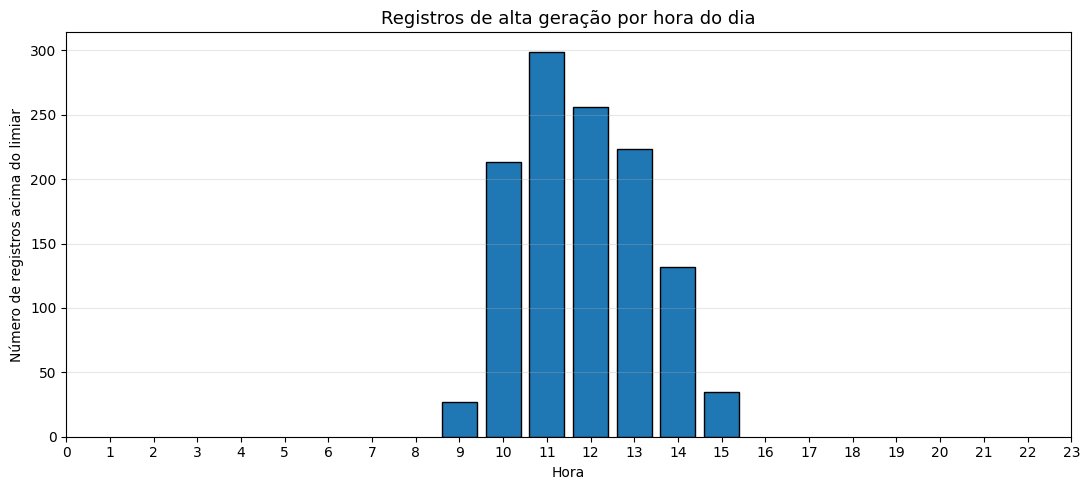

Faixa horária dos registros de alta geração:
  Primeira hora: 9h
  Última hora:   15h
  Hora de maior concentração: 11h


In [ ]:
if conversao_ok:
    dados['Hora'] = dados['DATA_HORA'].dt.hour
    df_alta_geracao = dados[dados['Potencia_CA'] > LIMIAR_70]

    fig, ax = plt.subplots(figsize=(11, 5))
    contagem_hora = df_alta_geracao['Hora'].value_counts().sort_index()
    ax.bar(contagem_hora.index, contagem_hora.values, edgecolor='black')
    ax.set_title('Registros de alta geração por hora do dia', fontsize=13)
    ax.set_xlabel('Hora')
    ax.set_ylabel('Número de registros acima do limiar')
    ax.set_xticks(range(0, 24))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Faixa horária dos registros de alta geração:')
    print(f'  Primeira hora: {contagem_hora.index.min()}h')
    print(f'  Última hora:   {contagem_hora.index.max()}h')
    print(f'  Hora de maior concentração: {contagem_hora.idxmax()}h')
else:
    print('Seção ignorada: DATE_TIME não pôde ser convertido.')

**Leitura:** a alta geração se concentra nas horas centrais do dia, em torno do meio-dia
solar, e desaparece completamente no início da manhã e no fim da tarde. O comportamento é
coerente com a curva de irradiância, o que serve como validação do recorte: o filtro por
limiar está capturando exatamente os períodos que fisicamente se espera que sejam de maior
geração.

---

## Exportação dos resultados (opcional)

In [ ]:
df_alta_geracao.to_csv('solar_alta_geracao.csv', index=False)
analise.to_csv('solar_analise_por_inversor.csv')

print('Arquivos gerados:')
print(' - solar_alta_geracao.csv         ->', len(df_alta_geracao), 'registros')
print(' - solar_analise_por_inversor.csv ->', len(analise), 'inversores')

Arquivos gerados:
 - solar_alta_geracao.csv         -> 1185 registros
 - solar_analise_por_inversor.csv -> 22 inversores


# **5. Wind & Solar Energy Production (Kaggle)**

In [29]:
import pandas as pd

dados = pd.read_csv("amostra_dataset5.csv")

In [30]:
Geracao_Solar = dados[dados["Source"] == "Solar"]["Production"]
Geracao_Eolica = dados[dados["Source"] == "Wind"]["Production"]

In [31]:
dados['Production'] = pd.to_numeric(dados['Production'], errors='coerce')

In [32]:
Geracao_Solar = dados[dados['Source'] == 'Solar']['Production']
Geracao_Eolica = dados[dados['Source'] == 'Wind']['Production']

In [33]:
maximo_solar = Geracao_Solar.max()
maximo_eolico = Geracao_Eolica.max()

In [34]:
P70_solar = 0.70 * maximo_solar
P70_eolico = 0.70 * maximo_eolico

print(P70_solar)
print(P70_eolico)

11421.199999999999
16050.3


In [35]:
df_alto_solar = dados[
    (dados['Source'] == 'Solar') &
    (dados['Production'] > P70_solar)
]

df_alto_eolico = dados[
    (dados['Source'] == 'Wind') &
    (dados['Production'] > P70_eolico)
]

In [ ]:
df_alto_solar

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
79,7/8/2025,13,14,Solar,189,Tuesday,July,Summer,13125.0
180,3/19/2025,13,14,Solar,78,Wednesday,March,Spring,13786.0
185,8/17/2025,12,13,Solar,229,Sunday,August,Summer,11455.0
189,7/16/2025,12,13,Solar,197,Wednesday,July,Summer,16160.0
209,3/31/2025,12,13,Solar,90,Monday,March,Spring,12441.0
817,7/11/2025,13,14,Solar,192,Friday,July,Summer,13057.0
926,9/13/2024,15,16,Solar,257,Friday,September,Fall,11435.0
946,3/2/2025,12,13,Solar,61,Sunday,March,Spring,12731.0
1188,7/5/2024,15,16,Solar,187,Friday,July,Summer,11741.0
1382,5/17/2023,11,12,Solar,137,Wednesday,May,Spring,12591.0


In [ ]:
df_alto_eolico

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
22,1/3/2024,0,1,Wind,3,Wednesday,January,Winter,17272.0
34,3/11/2021,13,14,Wind,70,Thursday,March,Spring,16144.0
105,1/29/2025,0,1,Wind,29,Wednesday,January,Winter,18199.0
153,12/8/2024,6,7,Wind,343,Sunday,December,Winter,16946.0
194,11/19/2024,2,3,Wind,324,Tuesday,November,Fall,16568.0
...,...,...,...,...,...,...,...,...,...
10191,1/31/2022,12,13,Wind,31,Monday,January,Winter,16588.0
10194,12/8/2024,9,10,Wind,343,Sunday,December,Winter,17595.0
10254,1/5/2025,8,9,Wind,5,Sunday,January,Winter,17589.0
10283,4/19/2024,14,15,Wind,110,Friday,April,Spring,18551.0


In [ ]:
qtd_solar = len(df_alto_solar)
qtd_eolico = len(df_alto_eolico)

percentual_solar = qtd_solar / len(dados) * 100
percentual_eolico = qtd_eolico / len(dados) * 100

print(f"Registros de alta geração solar: {qtd_solar}")
print(f"Percentual solar: {percentual_solar:.2f}%")

print(f"Registros de alta geração eólica: {qtd_eolico}")
print(f"Percentual eólico: {percentual_eolico:.2f}%")

Registros de alta geração solar: 45
Percentual solar: 0.43%
Registros de alta geração eólica: 245
Percentual eólico: 2.36%


In [ ]:
if percentual_solar > percentual_eolico:
    print("A geração solar aparece com maior frequência acima de 70% do seu próprio máximo.")
elif percentual_eolico > percentual_solar:
    print("A geração eólica aparece com maior frequência acima de 70% do seu próprio máximo.")
else:
    print("As duas fontes aparecem com a mesma frequência acima de 70% do seu próprio máximo.")

A geração eólica aparece com maior frequência acima de 70% do seu próprio máximo.


Não seria adequado usar o mesmo valor numérico como limite para as duas fontes porque a geração solar e a geração eólica podem apresentar escalas diferentes. Um valor considerado alto para uma fonte pode não representar um valor alto para a outra. Por isso, é mais adequado calcular o limite de 70% com base no próprio máximo de cada fonte, permitindo uma comparação mais justa.

# Dataset 06 (Setor de Energia)

In [ ]:
import pandas as pd

dados = pd.read_csv("Dataset06-preprocessado.csv")

dados = dados.rename(columns={
    "Date": "Data",
    "Global_active_power": "Pot_Ativa",
    "Global_reactive_power": "Pot_Reativa",
    "Voltage": "Tensao",
    "Global_intensity": "Corrente",
    "Sub_metering_1": "Sub_1",
    "Sub_metering_2": "Sub_2",
    "Sub_metering_3": "Sub_3"
})

dados.head()

,Data,Pot_Ativa,Pot_Reativa,Tensao,Corrente,Sub_1,Sub_2,Sub_3
0,1/12/2008,1.502,0.074,240.17,6.4,0.0,0.0,18.0
1,17/12/2006,0.374,0.264,245.50,1.8,0.0,2.0,0.0
2,3/6/2009,0.620,0.300,239.85,3.0,0.0,1.0,1.0
3,9/5/2007,0.280,0.200,235.72,1.4,0.0,0.0,0.0
4,14/12/2008,1.372,0.054,243.95,5.6,0.0,0.0,18.0


In [ ]:
p_max = dados['Pot_Ativa'].max()
print(f"Potência Ativa Máxima: {p_max:.3f} kW")

Potência Ativa Máxima: 10.536 kW


In [ ]:
p_75 = 0.75 * p_max
df_alto = dados[dados['Pot_Ativa'] > p_75]

print(f"Limite de 75% da Potência Ativa: {p_75:.3f} kW")
df_alto.head()

Limite de 75% da Potência Ativa: 7.902 kW


,Data,Pot_Ativa,Pot_Reativa,Tensao,Corrente,Sub_1,Sub_2,Sub_3
3132,24/1/2009,8.540,0.238,236.23,36.0,80.0,35.0,17.0
3630,9/1/2007,8.278,0.088,231.50,35.6,0.0,71.0,17.0
10339,4/11/2010,8.026,0.066,236.45,33.8,37.0,73.0,18.0
11695,5/4/2007,8.102,0.190,229.31,35.4,35.0,35.0,17.0
27983,19/10/2008,10.290,0.302,230.90,44.6,35.0,66.0,17.0


In [ ]:
qtd_alto = len(df_alto)
total = len(dados)
percentual_alto = (qtd_alto / total) * 100

print(f"Quantidade de registros: {qtd_alto}")
print(f"Percentual do total: {percentual_alto:.2f}%")

Quantidade de registros: 58
Percentual do total: 0.03%


In [ ]:
corrente_media = dados['Corrente'].mean()
print(f"Corrente Média: {corrente_media:.2f} A")

Corrente Média: 4.63 A


In [ ]:
df_duplo = dados[(dados['Pot_Ativa'] > p_75) & (dados['Corrente'] > corrente_media)]

qtd_duplo = len(df_duplo)
percentual_duplo = (qtd_duplo / total) * 100

print(f"Quantidade de registros: {qtd_duplo}")
print(f"Percentual do total: {percentual_duplo:.2f}%")
df_duplo.head()

Quantidade de registros: 58
Percentual do total: 0.03%


,Data,Pot_Ativa,Pot_Reativa,Tensao,Corrente,Sub_1,Sub_2,Sub_3
3132,24/1/2009,8.540,0.238,236.23,36.0,80.0,35.0,17.0
3630,9/1/2007,8.278,0.088,231.50,35.6,0.0,71.0,17.0
10339,4/11/2010,8.026,0.066,236.45,33.8,37.0,73.0,18.0
11695,5/4/2007,8.102,0.190,229.31,35.4,35.0,35.0,17.0
27983,19/10/2008,10.290,0.302,230.90,44.6,35.0,66.0,17.0


### 7. Comparação dos conjuntos e explicação do efeito da corrente

**Comparação quantitativa:**
- **Conjunto 1 (Potência Ativa > 75%):** 58 registros (0.03% do total).
- **Conjunto 2 (Potência Ativa > 75% e Corrente > Média):** 58 registros (0.03% do total).

**Interpretação e Efeito da Inclusão da Corrente:**
A inclusão da condição `Corrente > corrente_media` não alterou a quantidade de registros selecionados, mantendo-se exatamente em 58 registros.

Isso ocorre devido à relação física direta entre potência e corrente elétrica em circuitos ($P \approx V \cdot I$). Como o corte de 75% da potência máxima ($> 7.902\text{ kW}$) seleciona momentos de consumo elétrico extremo, a corrente associada a esses eventos também é extremamente alta (o menor valor de corrente observado nesse grupo é de $33.4\text{ A}$, bem acima da média geral da amostra de $4.63\text{ A}$).

Portanto, todo registro que atinge alta potência ativa já possui, naturalmente, uma corrente superior à média.